In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import sys
from jaxtyping import Float, Array, PRNGKeyArray

jax.config.update("jax_enable_x64", True)
sys.path.insert(0, "..")

In [75]:
from ctt.bases import make_canonical_polynomials, make_fourier

d = 2
n_features = 2
basis = make_canonical_polynomials(dim=n_features)
# basis = make_fourier(n_features)
# basis = lambda x: jnp.asarray([1., jax.nn.relu(x)])
key = random.PRNGKey(42)

In [76]:
@jax.jit
def target(x: Float[Array, "d"]) -> Float[Array, "m"]:
    # val = jnp.exp(-jnp.sum(x**2)/2)
    # val = 1./(1. + jnp.mean(x))
    # val = jnp.mean(x**2)
    val = 1./(1+jnp.prod(x))
    # val = jnp.sum(jnp.sin(2*jnp.pi*x))
    # val = jnp.prod((x >= 0.)*1.)
    # val = jnp.mean(jnp.exp(x))
    return jnp.atleast_1d(val)


In [77]:
from ctt.model import make_ctt

def lift(x: Float[Array, "d"]) -> Float[Array, "m"]:
    return jnp.hstack((0., x))

def retraction(x: Float[Array, "m"]) -> Float[Array, "o"]:
    return jnp.asarray((x[0],))

d_lift = jax.eval_shape(lift, jax.ShapeDtypeStruct((d,), dtype=float)).shape[0]
ctt = make_ctt(lift, retraction, basis, d)

In [ ]:
key, train_key, val_key = random.split(key, 3)

domain = (0., 1.)
N_train = 7000
X_train = random.uniform(key=train_key, shape=(N_train, d), minval=domain[0], maxval=domain[1])
# X_train = random.normal(key=train_key, shape=(N_train, d))
y_train = jax.vmap(target)(X_train)

N_val = 2000
X_val = random.uniform(key=val_key, shape=(N_val, d), minval=domain[0], maxval=domain[1])
# X_val = random.normal(key=val_key, shape=(N_val, d))
y_val = jax.vmap(target)(X_val)

num_steps = 2
regularization_coeff = 1e-8
radius = None
ranks = [d_lift] + [2] * (d_lift-1) + [1]

In [79]:
def dataloader(arrays: list, batch_size: int, *, key: PRNGKeyArray):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = random.permutation(key, indices)
        (key,) = random.split(key, 1)
        start = 0
        end = batch_size
        while end < dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size

In [80]:
import optax
from ctt.tt import tt_norm, TT

@jax.jit
def compute_loss(tts: list[TT],
                 x: Float[Array, "B d"],
                 y: Float[Array, "B d_o"],
                 alpha: float = 0.) -> tuple[float,float]:
    y_pred = jax.vmap(ctt, in_axes=(None, 0))(tts, x)
    # loss = jnp.mean(optax.l2_loss(y_pred, y))
    loss = jnp.mean(optax.l2_loss(y_pred, y))
    penalty = alpha*jnp.sum(jnp.asarray([tt_norm(u)**2 for u in tts]))
    return loss + penalty, loss

# Gradient Descent

In [81]:
def gradient_descent(train_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                     val_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                     optimizer: optax.GradientTransformation,
                     params: list[TT],
                     opt_steps: int,
                     regularization_coeff: float,
                     training_key: PRNGKeyArray,
                     batch_size: int = 64) -> tuple[list[TT], tuple[list[float], list[float]]]:
    X_train, y_train = train_dataset
    X_val, y_val = val_dataset
    opt_state = optimizer.init(params)
    train_losses = []
    val_losses = []

    @jax.jit
    def step(tts: list[TT],
             opt_state: optax.OptState,
             x: Float[Array, "B d"],
             y: Float[Array, "B d"],
             alpha: float = 0.):
        (loss, l2_error), grads = jax.value_and_grad(compute_loss, has_aux=True)(tts, x, y, alpha)
        updates, opt_state = optimizer.update(grads, opt_state, tts)
        params = optax.apply_updates(tts, updates)
        return params, opt_state, l2_error

    for i, (x, y) in zip(range(opt_steps), dataloader((X_train, y_train), batch_size, key=training_key)):
        params, opt_state, l2_error = step(params, 
                                            opt_state, 
                                            x,
                                            y,
                                            alpha=regularization_coeff)
        _, val_loss = compute_loss(params, X_val, y_val, alpha=0.)
        train_losses.append(l2_error)
        val_losses.append(val_loss)
        if i % 5 == 0:
            print(f"Iter {i} | Loss: {l2_error:.3e} | Val loss: {val_loss:.3e}")

    return params, (train_losses, val_losses)

# Natural gradient descent

In [89]:
import jax.flatten_util


def natural_gradient_descent(train_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                             val_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                             optimizer: optax.GradientTransformation,
                             params: list[TT],
                             opt_steps: int,
                             regularization_coeff: float,
                             training_key: PRNGKeyArray,
                             batch_size: int = 64) -> tuple[list[TT], tuple[list[float], list[float]]]:
    X_train, y_train = train_dataset
    X_val, y_val = val_dataset
    opt_state = optimizer.init(params)
    train_losses = []
    val_losses = []

    def tree_mvp_dampen(mvp, lmbda=0.1):
        dampen_fcn = lambda mvp_, v_: mvp_ + lmbda * v_
        damp_mvp = lambda v: jax.tree.map(dampen_fcn, mvp(v), v)
        return damp_mvp

    def _natural_grad(tts: list[TT], x: Float[Array, "B d"], grads: list[TT]) -> list[TT]:
        f = lambda w: jax.vmap(ctt, in_axes=(None,0))(w, x).ravel() / jnp.sqrt(x.shape[0])
        fvp = lambda v: jax.vjp(f, tts)[1](jax.jvp(f, (tts,), (v,))[1])[0]
        fvp = tree_mvp_dampen(fvp, lmbda=1e-8)
        ngrad, _ = jax.scipy.sparse.linalg.cg(fvp, grads, maxiter=10)
        return ngrad

    @jax.jit
    def step(tts: list[TT],
             opt_state: optax.OptState,
             x: Float[Array, "B d"],
             y: Float[Array, "B d"],
             alpha: float = 0.):
        (loss, l2_error), grads = jax.value_and_grad(compute_loss, has_aux=True)(tts, x, y, alpha)
        ngrad = _natural_grad(tts, x, grads)
        updates, opt_state = optimizer.update(ngrad, opt_state, tts)
        params = optax.apply_updates(tts, updates)
        return params, opt_state, l2_error

    for i, (x, y) in zip(range(opt_steps), dataloader((X_train, y_train), batch_size, key=training_key)):
        params, opt_state, l2_error = step(params, 
                                            opt_state, 
                                            x,
                                            y,
                                            alpha=regularization_coeff)
        _, val_loss = compute_loss(params, X_val, y_val, alpha=0.)
        train_losses.append(l2_error)
        val_losses.append(val_loss)
        if i % 5 == 0:
            print(f"Iter {i} | Loss: {l2_error:.3e} | Val loss: {val_loss:.3e}")

    return params, (train_losses, val_losses)

# Comparison

In [83]:
from ctt.tt import tt_zeros, tt_randn

key, *control_keys = random.split(key, num_steps+1)
key, training_key = random.split(key)

init_controls = [
    tt_randn(control_key, [n_features] * d_lift, ranks, cov=1.0)
    for control_key in control_keys
]
zero_init_controls = [
    tt_zeros([n_features] * d_lift, ranks)
    for _ in range(num_steps)
]
print(list(map(tt_norm, init_controls)))

[Array(0.01087718, dtype=float64), Array(0.03696398, dtype=float64)]


## Gradient descent

In [91]:
optimizer = optax.adam(learning_rate=1e-3)
# optimizer = optax.sgd(learning_rate=1e-1)
params_gd, (train_losses_gd, val_losses_gd) = gradient_descent(train_dataset=(X_train, y_train),
                                                               val_dataset=(X_val, y_val),
                                                               optimizer=optimizer,
                                                               params=init_controls,
                                                               opt_steps=10000,
                                                               regularization_coeff=1e-4,
                                                               batch_size=64,
                                                               training_key=training_key)

Iter 0 | Loss: 3.444e-01 | Val loss: 3.446e-01
Iter 5 | Loss: 3.545e-01 | Val loss: 3.435e-01
Iter 10 | Loss: 3.608e-01 | Val loss: 3.422e-01
Iter 15 | Loss: 3.518e-01 | Val loss: 3.409e-01
Iter 20 | Loss: 3.548e-01 | Val loss: 3.394e-01
Iter 25 | Loss: 3.508e-01 | Val loss: 3.377e-01
Iter 30 | Loss: 3.313e-01 | Val loss: 3.358e-01
Iter 35 | Loss: 3.309e-01 | Val loss: 3.336e-01
Iter 40 | Loss: 3.424e-01 | Val loss: 3.312e-01
Iter 45 | Loss: 3.306e-01 | Val loss: 3.284e-01
Iter 50 | Loss: 3.161e-01 | Val loss: 3.252e-01
Iter 55 | Loss: 3.357e-01 | Val loss: 3.216e-01
Iter 60 | Loss: 3.133e-01 | Val loss: 3.174e-01
Iter 65 | Loss: 3.108e-01 | Val loss: 3.128e-01
Iter 70 | Loss: 3.027e-01 | Val loss: 3.076e-01
Iter 75 | Loss: 2.975e-01 | Val loss: 3.017e-01
Iter 80 | Loss: 2.894e-01 | Val loss: 2.951e-01
Iter 85 | Loss: 3.061e-01 | Val loss: 2.878e-01
Iter 90 | Loss: 2.962e-01 | Val loss: 2.796e-01
Iter 95 | Loss: 2.759e-01 | Val loss: 2.705e-01
Iter 100 | Loss: 2.472e-01 | Val loss: 2.6

## Natural gradient descent

In [109]:
# optimizer = optax.adam(learning_rate=1e-3)
optimizer = optax.sgd(learning_rate=1e-4, momentum=0.9)
params_ngd, (train_losses_ngd, val_losses_ngd) = natural_gradient_descent(train_dataset=(X_train, y_train),
                                                                       val_dataset=(X_val, y_val),
                                                                       optimizer=optimizer,
                                                                       params=init_controls,
                                                                       opt_steps=10000,
                                                                       regularization_coeff=1e-7,
                                                                       batch_size=32,
                                                                       training_key=training_key)

Iter 0 | Loss: 3.363e-01 | Val loss: 3.448e-01
Iter 5 | Loss: 3.839e-01 | Val loss: 3.436e-01
Iter 10 | Loss: 3.634e-01 | Val loss: 3.414e-01
Iter 15 | Loss: 3.443e-01 | Val loss: 3.384e-01
Iter 20 | Loss: 3.441e-01 | Val loss: 3.351e-01
Iter 25 | Loss: 3.535e-01 | Val loss: 3.314e-01
Iter 30 | Loss: 3.301e-01 | Val loss: 3.275e-01
Iter 35 | Loss: 3.445e-01 | Val loss: 3.236e-01
Iter 40 | Loss: 3.418e-01 | Val loss: 3.197e-01
Iter 45 | Loss: 3.124e-01 | Val loss: 3.158e-01
Iter 50 | Loss: 3.145e-01 | Val loss: 3.118e-01
Iter 55 | Loss: 3.041e-01 | Val loss: 3.079e-01
Iter 60 | Loss: 3.065e-01 | Val loss: 3.041e-01
Iter 65 | Loss: 2.851e-01 | Val loss: 3.004e-01
Iter 70 | Loss: 3.087e-01 | Val loss: 2.968e-01
Iter 75 | Loss: 2.958e-01 | Val loss: 2.933e-01
Iter 80 | Loss: 3.150e-01 | Val loss: 2.899e-01
Iter 85 | Loss: 2.681e-01 | Val loss: 2.866e-01
Iter 90 | Loss: 2.829e-01 | Val loss: 2.834e-01
Iter 95 | Loss: 2.664e-01 | Val loss: 2.802e-01
Iter 100 | Loss: 2.754e-01 | Val loss: 2.7

## Plotting the errors

Text(0, 0.5, 'Error')

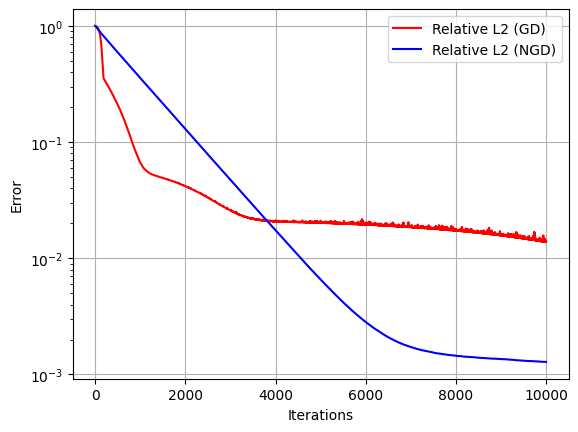

In [110]:
fig, ax = plt.subplots()

y_val_norm = jnp.mean(optax.l2_loss(jnp.zeros_like(y_val), y_val))

# plot GD losses
val_losses_gd = jnp.asarray(val_losses_gd)

ax.semilogy(jnp.arange(len(val_losses_gd)), jnp.sqrt(val_losses_gd/y_val_norm), label="Relative L2 (GD)", color="red")

# plot NGD losses
val_losses_ngd = jnp.asarray(val_losses_ngd)

ax.semilogy(jnp.arange(len(val_losses_ngd)), jnp.sqrt(val_losses_ngd/y_val_norm), label="Relative L2 (NGD)", color="blue")

ax.grid()
ax.legend()
ax.set_xlabel("Iterations")
ax.set_ylabel("Error")